7


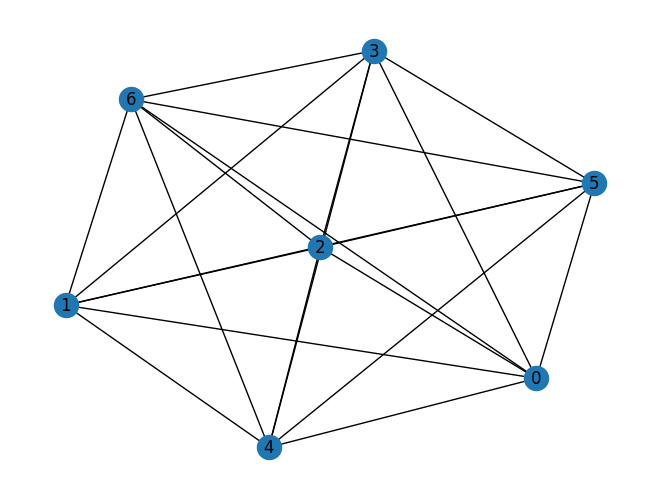

In [ ]:
from qaoamis import QAOAMIS

mis = QAOAMIS()

mis.addNodes(7)

mis.addEdges([
    (0, 1), (0, 2), (0, 3), (0, 4), (0, 5), (0, 6),
    (1, 2), (1, 3), (1, 4), (1, 5), (1, 6),
    (2, 3), (2, 4), (2, 5), (2, 6),
    (3, 4), (3, 5), (3, 6),
    (4, 5), (4, 6),
    (5, 6)
])
penalty = mis.n

mis.visualize()

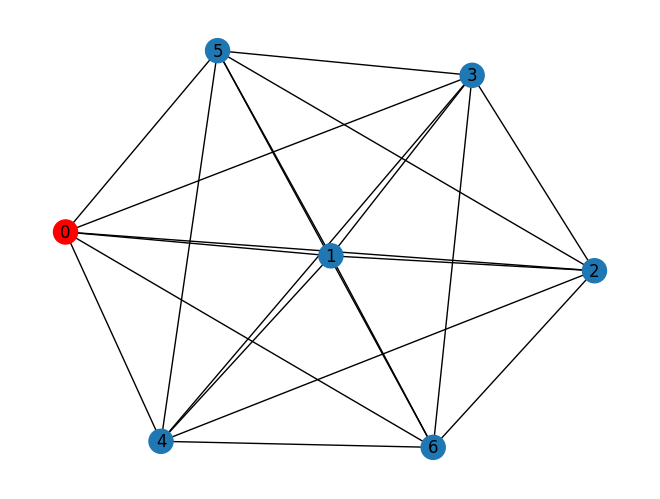

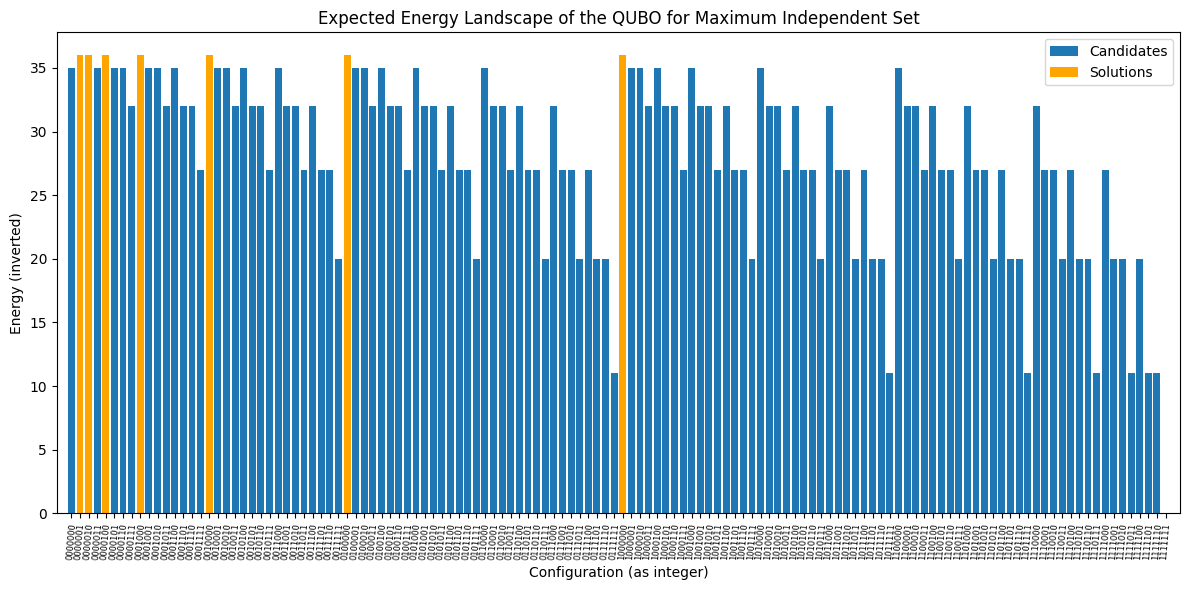

In [2]:
mis.buildQUBO(penalty=penalty)
brute_force_sol = mis.mis_brute_force(show_graph=True, print_expected_energy_bar=True)

In [3]:
mis.buildCostHamiltonian(penalty=penalty)
circuit = mis.buildQAOAAnsatz(layers=5)

print(circuit)

     ┌──────────────────────────────────────────────────────────┐
q_0: ┤0                                                         ├
     │                                                          │
q_1: ┤1                                                         ├
     │                                                          │
q_2: ┤2                                                         ├
     │                                                          │
q_3: ┤3 QAOA(γ[0],β[0],γ[1],β[1],γ[2],β[2],γ[3],β[3],γ[4],β[4]) ├
     │                                                          │
q_4: ┤4                                                         ├
     │                                                          │
q_5: ┤5                                                         ├
     │                                                          │
q_6: ┤6                                                         ├
     └──────────────────────────────────────────────────────────┘


In [4]:
beta, gamma = mis.find_optimal_parameters()

/home/tuthuanvanvn/miniconda3/envs/molssi_best_practices/lib/python3.11/site-packages/scipy/sparse/linalg/_dsolve/linsolve.py:597: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
/home/tuthuanvanvn/miniconda3/envs/molssi_best_practices/lib/python3.11/site-packages/scipy/sparse/linalg/_matfuncs.py:707: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)
/home/tuthuanvanvn/miniconda3/envs/molssi_best_practices/lib/python3.11/site-packages/scipy/sparse/_index.py:168: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


[1.5740137  1.21882874 1.54527091 1.4210565  1.60688888] [2.93216127 3.49266211 3.37488892 3.55469182 3.16888706]


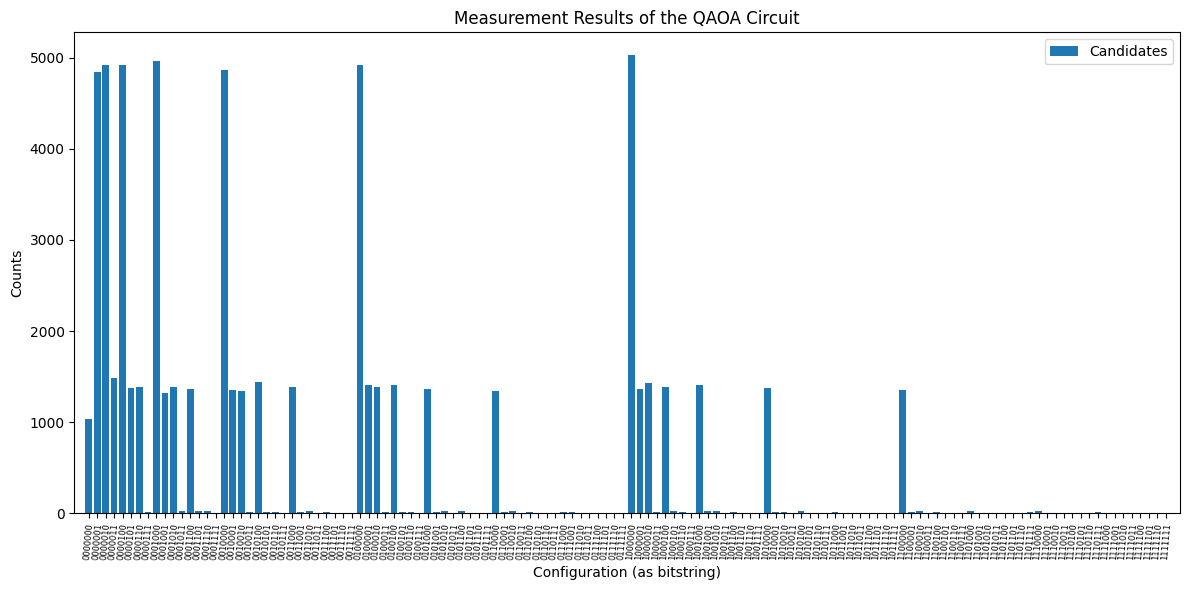

{np.str_('0000000'): np.int64(1034),
 np.str_('0000001'): np.int64(4841),
 np.str_('0000010'): np.int64(4923),
 np.str_('0000011'): np.int64(1484),
 np.str_('0000100'): np.int64(4913),
 np.str_('0000101'): np.int64(1380),
 np.str_('0000110'): np.int64(1387),
 np.str_('0000111'): np.int64(14),
 np.str_('0001000'): np.int64(4958),
 np.str_('0001001'): np.int64(1325),
 np.str_('0001010'): np.int64(1391),
 np.str_('0001011'): np.int64(25),
 np.str_('0001100'): np.int64(1359),
 np.str_('0001101'): np.int64(22),
 np.str_('0001110'): np.int64(25),
 np.str_('0001111'): np.int64(8),
 np.str_('0010000'): np.int64(4863),
 np.str_('0010001'): np.int64(1358),
 np.str_('0010010'): np.int64(1337),
 np.str_('0010011'): np.int64(15),
 np.str_('0010100'): np.int64(1438),
 np.str_('0010101'): np.int64(15),
 np.str_('0010110'): np.int64(20),
 np.str_('0010111'): np.int64(6),
 np.str_('0011000'): np.int64(1386),
 np.str_('0011001'): np.int64(20),
 np.str_('0011010'): np.int64(21),
 np.str_('0011011'): np.i

In [5]:
print(beta, gamma)
mis.qaoa_evaluate(beta, gamma, shots=2 ** 16, print_count=True)